In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
import torch.nn as nn
from torch.optim import Adam


In [2]:

train_protocol = Path(r"/home/achaammamathayi/Academia/Projects/Datasets/ASVSpoof19/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol = Path(r"/home/achaammamathayi/Academia/Projects/Datasets/ASVSpoof19/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
eval_protocol = Path(r"/home/achaammamathayi/Academia/Projects/Datasets/ASVSpoof19/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")
train_path = Path(r"/home/achaammamathayi/Academia/Projects/Datasets/ASVSpoof19/LA/ASVspoof2019_LA_train/flac")
dev_path = Path(r"/home/achaammamathayi/Academia/Projects/Datasets/ASVSpoof19/LA/ASVspoof2019_LA_dev/flac")
eval_path = Path(r"/home/achaammamathayi/Academia/Projects/Datasets/ASVSpoof19/LA/ASVspoof2019_LA_eval/flac")


In [20]:
# Refined Dataset class
class ASVDataset(Dataset):
    def __init__(self, audio_folder, label_file):
        super().__init__()
        self.audio_folder = audio_folder
        self.label_file = label_file
        self.label_tuple = self.parser()

# Parser function
    def parser(self):
        self.label_tuple = []
        with open(self.label_file, 'r') as f:
            for line in f:
                parts = line.split()
                file_name = parts[1] + '.flac'
                bonorpspoof = 0 if parts[4] == 'bonafide' else 1
                self.label_tuple.append([file_name,bonorpspoof])
        return self.label_tuple
    
    def __len__(self):
        return len(self.label_tuple)
    
    def __getitem__(self, index):
        # Plan: extract audio from the full_path. link it with the label. That should give something like mfcc sample, label.
        audio_path = self.audio_folder.joinpath(self.label_tuple[index][0])
        try:
            m, sr = librosa.load(path=audio_path,sr=16000)
        except FileNotFoundError as e:
            print(f"FILE MISSING: {e}")
            raise
        mfcc = librosa.feature.mfcc(y=m, n_mfcc=20,)
        if mfcc.shape[1] > 125:
            mfcc = mfcc[:, : 125]
        elif mfcc.shape[1] == 125:
            pass
        elif mfcc.shape[1] < 125:
            pad_size = 125 - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0), (0, pad_size)), 'constant', constant_values=0)
        x = torch.tensor(mfcc, dtype=torch.float32)
        y= torch.tensor(self.label_tuple[index][1])
        return x,y

In [21]:
# DataLoader class
train_dataset = ASVDataset(train_path,train_protocol)
dev_dataset = ASVDataset(dev_path, dev_protocol)
eval_dataset = ASVDataset(eval_path, eval_protocol)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,drop_last=True)
dev_loader = DataLoader(dev_dataset, batch_size=128, shuffle=False, drop_last=False)
eval_loader = DataLoader(eval_dataset, batch_size=128, shuffle=False, drop_last=False)

In [22]:
# Model design
class ASVCNN(nn.Module):
    def __init__(self, input_size=1, num_classes = 1):
        super(ASVCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size, out_channels=32, kernel_size=(3,5), stride=1, padding=(1,2)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # might have to change the pooling kernel stride to an overlapping one after the training
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))
        )
        self.layer2 = nn.Sequential(
            #kernel size remains the same, hence the padding and striding as well
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,5), stride=1, padding=(1,2)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #changing the pooling kernel size so that the layer 1 feautremap are made in a higher resolution feature map.
            #no pooling around mfcc axis, only pooling along time frame axis
            nn.MaxPool2d(kernel_size=(1,2), stride=(1,2))
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,5), stride=1, padding=(1,2)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))
        )
        #classification layers
        self.linear1 = nn.Sequential(
            nn.Linear(9600,128),
            nn.ReLU()
        )
        self.linear2 = nn.Linear(128, num_classes)

    def forward(self,x):
        x = self.layer1(x)
        print('layer1: ',x.shape)
        x = self.layer2(x)
        print('layer 2',x.shape)
        x = self.layer3(x)
        print('layer 3',x.shape)

        #flattening x
        x = torch.flatten(x, start_dim=1)
        print('after flattening',x.shape)

        x = self.linear1(x)
        print('linear 1:', x.shape)
        x = self.linear2(x)
        print('linear 2:',x.shape)
        return x

In [ ]:
# the training loop
def train_epoch(model, dataloader, criterion, optimizer, device):

    running_loss = 0
    model.train()

    for sample, label in dataloader:
        sample = sample.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        output = model(sample)
        label = (label.view(-1,1)).float()
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    return running_loss/len(dataloader)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ASVCNN().to(device)
dataloader = train_loader
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 1e-3)

epochs = 30

for epoch in range(epochs):
    epoch_loss = train_epoch(model, dataloader, criterion, optimizer, device)
    print(f'Epoch: {epoch+1} __ Loss: {epoch_loss: .4f}')


In [36]:
# testing the model with a dummy input
dummpy_input = torch.randn(64,1,20,125)
print(f'The shape of the dummy input: {dummpy_input.shape}')

model = ASVCNN()
model.eval()

with torch.no_grad():
    model_output = model(dummpy_input)


print(f'The output shape is {model_output.shape}')

The shape of the dummy input: torch.Size([64, 1, 20, 125])
layer1:  torch.Size([64, 32, 10, 62])
layer 2 torch.Size([64, 64, 10, 31])
layer 3 torch.Size([64, 128, 5, 15])
after flattening torch.Size([64, 9600])
linear 1: torch.Size([64, 128])
linear 2: torch.Size([64, 1])
The output shape is torch.Size([64, 1])


In [ ]:
# Initial draft for Dataset class
class ASVDataset(Dataset):
    def __init__(self, audio_folder, label_file):
        super().__init__()
        self.audio_folder = audio_folder
        self.label_file = label_file
        self.label_tuple = []
        self.parser = self.parser(label_file)

# Parser function
    def parser(self):
        self.label_tuple = []
        with open(self.label_file, 'r') as f:
            for line in f:
                parts = line.split()
                file_name = parts[1] + '.flac'
                if parts[4] == 'bonafide':
                    parts[4] = 0
                    pass
                elif parts[4] == 'spoof':
                    parts[4] = 1
                bonorpspoof = parts[4]
                self.label_tuple.append([file_name,bonorpspoof])
        return self.label_tuple
    
# Looks like the Parser function gives out the tuple as ['LA_T_1138215.flac', 0] . We need only the [mfcc, label]. So creating another 
# for loop for the time being. The optimizaiton will be carried out later.
    def label_extractor(self):
        self.label_only = []
        for  pairedlabel in self.label_tuple:
            self.label_only.append(pairedlabel[1])
        return self.label_only

# Mapping the extracted filename to the path    
    def mapper(self):
        self.full_path = []
        for i in self.label_tuple:
            audio_path = train_path.joinpath(i[0])
            self.full_path.append(audio_path)
        return self.full_path
    
    def __len__(self):
        return len(self.label_tuple)
    
    def __getitem__(self, index):
        # Plan: extract audio from the full_path. link it with the label. That should give something like mfcc sample, label.
        if Path(self.full_path).exists():
            y, sr = librosa.load(path=self.full_path[index],sr=16000)
            self.mfcc = librosa.feature.mfcc(y=y, n_mfcc=20,)
            if self.mfcc.shape[1] > 125:
                self.mfcc = self.mfcc[:, : 125]
            elif self.mfcc.shape[1] == 125:
                pass
            elif self.mfcc.shape[1] < 125:
                pad_size = 125 - self.mfcc.shape[1]
                self.mfcc = np.pad(mfcc, ((0,0), (0, pad_size)), 'constant', constant_values=0)
        x = torch.tensor(self.mfcc, dtype=float32)
        y= torch.tensor(self.label_only[index])
        return x,y

In [4]:
#workspace for parser function
p = train_protocol
label_tuple = []
with open(p, 'r') as f:
    for line in f:
        parts = line.split()
        for value in parts[3]:
            if value == '-':
                parts[3] = None
        attacker = parts[3]
        if parts[4] == 'bonafide':
            parts[4] = 0
            pass
        elif parts[4] == 'spoof':
            parts[4]=1
        bonorspoof = parts[4]
        filename = parts[1] + '.flac'
        label_tuple.append([filename,bonorspoof])
    print(label_tuple)

# Parser function succesfully tried.


[['LA_T_1138215.flac', 0], ['LA_T_1271820.flac', 0], ['LA_T_1272637.flac', 0], ['LA_T_1276960.flac', 0], ['LA_T_1341447.flac', 0], ['LA_T_1363611.flac', 0], ['LA_T_1596451.flac', 0], ['LA_T_1608170.flac', 0], ['LA_T_1684951.flac', 0], ['LA_T_1699801.flac', 0], ['LA_T_1703395.flac', 0], ['LA_T_1736342.flac', 0], ['LA_T_1779188.flac', 0], ['LA_T_1786825.flac', 0], ['LA_T_1787246.flac', 0], ['LA_T_1905558.flac', 0], ['LA_T_2205687.flac', 0], ['LA_T_2220901.flac', 0], ['LA_T_2361751.flac', 0], ['LA_T_2373806.flac', 0], ['LA_T_2417641.flac', 0], ['LA_T_2520083.flac', 0], ['LA_T_2562689.flac', 0], ['LA_T_2564579.flac', 0], ['LA_T_2732709.flac', 0], ['LA_T_2759900.flac', 0], ['LA_T_2838981.flac', 0], ['LA_T_2873890.flac', 0], ['LA_T_2938316.flac', 0], ['LA_T_3131990.flac', 0], ['LA_T_3141223.flac', 0], ['LA_T_3167734.flac', 0], ['LA_T_3187715.flac', 0], ['LA_T_3215578.flac', 0], ['LA_T_3247389.flac', 0], ['LA_T_3346004.flac', 0], ['LA_T_3441957.flac', 0], ['LA_T_3561136.flac', 0], ['LA_T_3576

In [6]:
# Mapping function
whole_path = []
for j in label_tuple:
    audio_path = train_path.joinpath(j[0])
    whole_path.append(audio_path)

In [8]:
# So for padding/truncating, we are going to need to know the ideal duration for audio files in which the details are
# preserved for long and short clips.
audio_dur = []
for file in whole_path:
    try:
        file_duration = librosa.get_duration(path=file)
        audio_dur.append(file_duration)
    except FileNotFoundError as e:
        print(f'Whoopsie Daise file not found {e}')


C:\Users\aswat\AppData\Local\Temp\ipykernel_10268\2875039068.py:6: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  file_duration = librosa.get_duration(path=file)


Whoopsie Daise file not found [Errno 2] No such file or directory: 'C:\\Mathayi\\Projects\\Dataset\\ASVSpoof19\\LA\\ASVspoof2019_LA_train\\flac\\LA_T_9667455.flac'


Mean:3.4258471620237203 
 Median:3.2016875 
 Minimum:0.6524375 
 Maximum:13.1879375


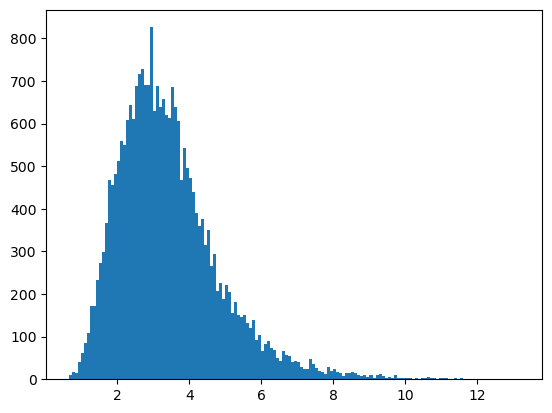

In [26]:
mean = np.mean(audio_dur)
median = np.median(audio_dur)
min_dur = np.min(audio_dur)
max_dur = np.max(audio_dur)
print(f"Mean:{mean} \n Median:{median} \n Minimum:{min} \n Maximum:{max}")
plt.hist(audio_dur, bins=150)
plt.show()

In [11]:
# testing mfcc extractor for __getitem__ class
mfcc_val = []
# torched_mfcc = []
for k in whole_path:
    try:
        y, sr = librosa.load(Path(k),sr=16000)
        mfcc = librosa.feature.mfcc(y=y, n_mfcc=20,)
        mfcc_val.append(mfcc)
        # torching_mfcc = torch.tensor(mfcc)
        # torched_mfcc.append(torching_mfcc)
    except FileNotFoundError as e:
        print(f'Blyat! This file fucked up: {e}')
# torched_mfcc
mfcc_val

C:\Users\aswat\AppData\Local\Temp\ipykernel_10268\2565660435.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(Path(k),sr=16000)
c:\Mathayi\Installations\MiniConda\envs\dlvenv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Blyat! This file fucked up: [Errno 2] No such file or directory: 'C:\\Mathayi\\Projects\\Dataset\\ASVSpoof19\\LA\\ASVspoof2019_LA_train\\flac\\LA_T_9667455.flac'


[array([[-555.3609   , -560.5831   , -563.77606  , ..., -558.6323   ,
         -562.66016  , -564.63586  ],
        [  24.845621 ,   18.017818 ,   13.529783 , ...,   18.822132 ,
           15.111382 ,   12.495664 ],
        [  22.234833 ,   16.937054 ,   12.536821 , ...,   14.0115595,
           14.12735  ,   12.017502 ],
        ...,
        [  -4.966499 ,   -4.915187 ,   -3.3843598, ...,   -1.4984632,
           -5.0045433,   -4.843523 ],
        [  -5.071816 ,   -5.198991 ,   -4.267213 , ...,   -3.5419688,
           -5.4211683,   -5.0316567],
        [  -4.934209 ,   -5.4888363,   -5.2186384, ...,   -5.451953 ,
           -5.8156605,   -5.090373 ]], shape=(20, 109), dtype=float32),
 array([[-532.32355  , -535.1909   , -538.24023  , ..., -539.9615   ,
         -537.9897   , -536.3962   ],
        [  19.22145  ,   15.475977 ,   11.2428665, ...,    8.786986 ,
           11.491343 ,   13.656687 ],
        [  17.791115 ,   14.872767 ,   10.868877 , ...,    8.353369 ,
           10.81091

In [53]:
mfcc_val[0]

array([[-555.3609   , -560.5831   , -563.77606  , ..., -558.6323   ,
        -562.66016  , -564.63586  ],
       [  24.845621 ,   18.017818 ,   13.529783 , ...,   18.822132 ,
          15.111382 ,   12.495664 ],
       [  22.234833 ,   16.937054 ,   12.536821 , ...,   14.0115595,
          14.12735  ,   12.017502 ],
       ...,
       [  -4.966499 ,   -4.915187 ,   -3.3843598, ...,   -1.4984632,
          -5.0045433,   -4.843523 ],
       [  -5.071816 ,   -5.198991 ,   -4.267213 , ...,   -3.5419688,
          -5.4211683,   -5.0316567],
       [  -4.934209 ,   -5.4888363,   -5.2186384, ...,   -5.451953 ,
          -5.8156605,   -5.090373 ]], shape=(20, 109), dtype=float32)

In [ ]:
len(mfcc_val[0][7,:])

109

In [64]:
mfcc_val[0].shape[1]

109

In [ ]:
# testing padding and truncation
for shotta in mfcc_val:
    if shotta.shape[0] > 125:
        shotta_truncated = shotta[: ,:125]
        pass
    elif shotta.shape[0] < 125:
        pad_size = 125- shotta.shape[0]
        shotta_padded = np.pad(shotta, ((0,0), (0,pad_size)), 'constant', constant_values= 0)

In [18]:
a = np.ones((4,5))
a
b = np.pad(a, ((0,0), (0,5)), 'constant', constant_values=0)
b

array([[1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.]])

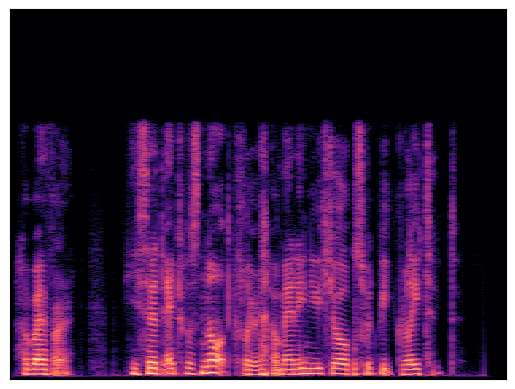

In [ ]:
#Workspace for feature extraction with librosa, stft for the time being.
y, sr = librosa.load(r"C:\Mathayi\Projects\Dataset\ASVSpoof19\LA\ASVspoof2019_LA_train\flac\LA_T_5308888.flac")
stft_s = librosa.stft(y=y,n_fft=2048, hop_length=512)
magnitude = np.abs(stft_s)
stft_spec_db = librosa.amplitude_to_db(magnitude, ref=np.max)
spec = librosa.display.specshow(stft_spec_db)

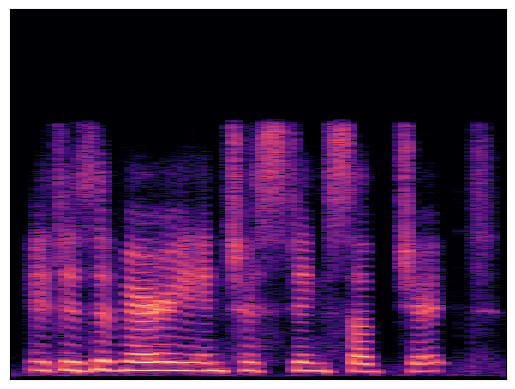

In [ ]:
#Workspace for feature extraction with librosa, stft for the time being.
y, sr = librosa.load(r"C:\Mathayi\Projects\Dataset\ASVSpoof19\LA\ASVspoof2019_LA_train\flac\LA_T_1000648.flac")
stft_s = librosa.stft(y=y,n_fft=2048, hop_length=512)
magnitude = np.abs(stft_s)
stft_spec_db = librosa.amplitude_to_db(magnitude, ref=np.max)
spec = librosa.display.specshow(stft_spec_db)